# **[W2] TASK**

- 작업 챕터: 03-3장. 특성 공학과 규재

- 주요 질문:  
    1. 고차 다항 회귀를 적용했을 때 Test Score가 -144로 매우 낮게 나와 과적합이 발생한 것을 확인. **만약 여기에 Ridge나 Lasso를 적용한다면 규제 강도(alpha) 값을 적절히 결정하는 방법으로는 무엇이 있는가**
    
    2. Ridge와 Lasso 회귀는 데이터의 특성 계수를 변형하여 효과를 내는 기법임. **그렇다면 데이터 특성 수가 많을 때 어떤 기법을 주로 쓰는가?**

    3. 모델 학습 전 scaler를 사용하는데 **규제 모델에서 sclaer가 결과에 어떤 결정적인 영향을 미치는가?**

In [13]:
# 기본 설정
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
# 농어 데이터 불러오기(Pandas)
perch_full = pd.read_csv("https://bit.ly/perch_csv_data")
perch_full.head()

,length,height,width
0,8.4,2.11,1.41
1,13.7,3.53,2.00
2,15.0,3.82,2.43
3,16.2,4.59,2.63
4,17.4,4.59,2.94


In [15]:
# 타겟 데이터 불러오기
perch_length = np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 21.0,
       21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 22.5, 22.7,
       23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 27.3, 27.5, 27.5,
       27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 36.5, 36.0, 37.0, 37.0,
       39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 40.0, 42.0, 43.0, 43.0, 43.5,
       44.0])
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0])


In [16]:
# 데이터 분할
from sklearn.model_selection import train_test_split
train_input, test_input,train_target, test_target = train_test_split(perch_full, perch_weight, random_state=42)

## **1. 다중 회귀**

In [17]:
# 특성 변환
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures()

poly.fit([[2,3]])
print(poly.transform([[2,3]]))

[[1. 2. 3. 4. 6. 9.]]


In [18]:
poly = PolynomialFeatures(include_bias=False)
poly.fit(train_input)
train_poly = poly.transform(train_input)
print(train_poly.shape)

(42, 9)


In [19]:
# 메서드 확인
poly.get_feature_names_out()

array(['length', ' height', ' width', 'length^2', 'length  height',
       'length  width', ' height^2', ' height  width', ' width^2'],
      dtype=object)

In [20]:
# 테스트 세트 변환
test_poly = poly.transform(test_input)

In [21]:
# 다중 회귀 모델 학습
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(train_poly, train_target)

print(f"train score: {lr.score(train_poly, train_target)}")
print(f"test score: {lr.score(test_poly, test_target)}")

train score: 0.9903183436982125
test score: 0.9714559911594111


## **2. 다중 회귀_2**

In [22]:
# 고차항 차수 생성
poly = PolynomialFeatures(degree=5, include_bias=False)

poly.fit(train_input)

train_poly = poly.transform(train_input)
test_poly = poly.transform(test_input)

print(train_poly.shape)

(42, 55)


In [24]:
# 고차항 다중 회귀 학습
lr.fit(train_poly, train_target)

print(f"train score: {lr.score(train_poly, train_target)}")
print(f"test score: {lr.score(test_poly, test_target)}")

# test score = -144 > 과적합 발생

train score: 0.9999999999996433
test score: -144.40579436844948


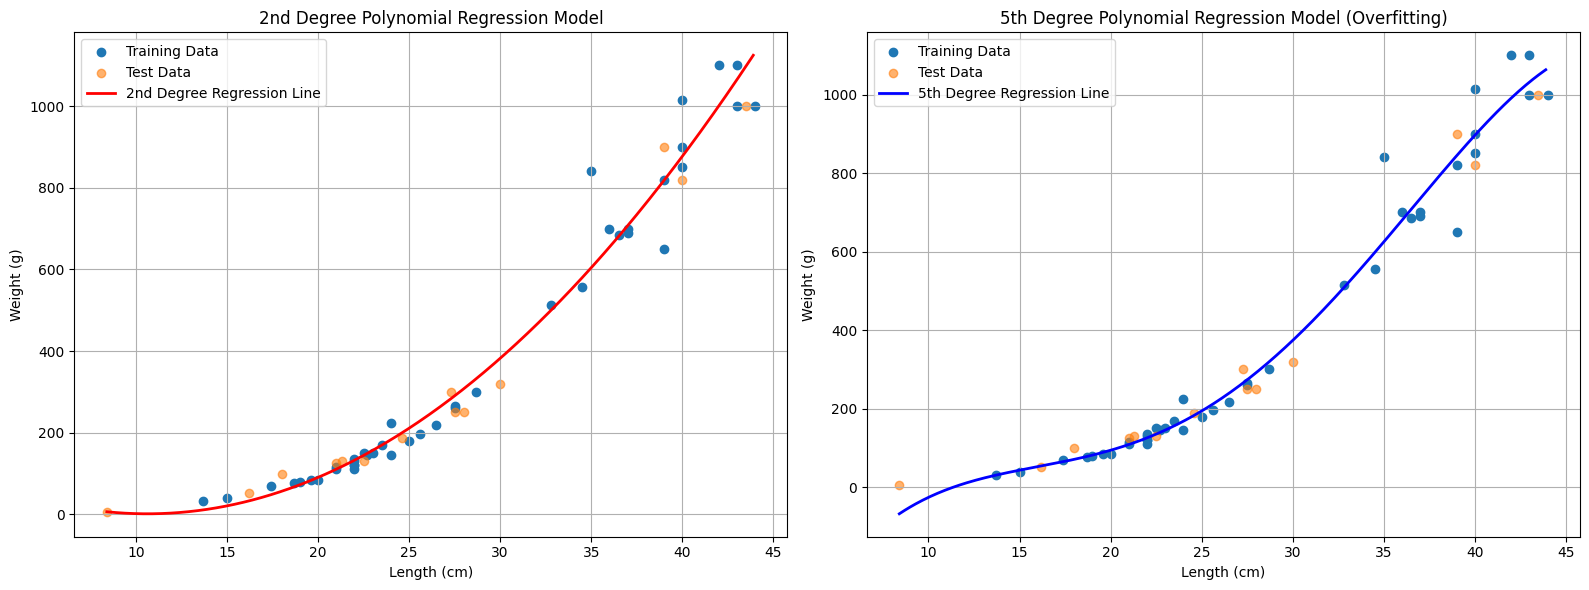

In [25]:
# 시각화를 위해 'length' 특성만 사용하여 모델 재학습 및 예측
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# perch_length (1D)를 scikit-learn 입력 형식인 2D 배열로 변환
perch_length_reshaped = perch_length.reshape(-1, 1)

# length와 weight 데이터만 사용하여 훈련/테스트 세트 분할
train_input_len, test_input_len, train_target_len, test_target_len = train_test_split(
    perch_length_reshaped, perch_weight, random_state=42
)

# --- 모델 1: 2차 다항 회귀  ---
# 2차 다항 특성 생성기 초기화 및 학습 (include_bias=False로 상수항은 선형 모델이 처리하도록)
poly_deg2 = PolynomialFeatures(degree=2, include_bias=False)
poly_deg2.fit(train_input_len)
train_poly_deg2 = poly_deg2.transform(train_input_len)

# 2차 다항 회귀 모델 학습
lr_deg2 = LinearRegression()
lr_deg2.fit(train_poly_deg2, train_target_len)

# --- 모델 2: 5차 다항 회귀  ---
# 5차 다항 특성 생성기 초기화 및 학습
poly_deg5 = PolynomialFeatures(degree=5, include_bias=False)
poly_deg5.fit(train_input_len)
train_poly_deg5 = poly_deg5.transform(train_input_len)

# 5차 다항 회귀 모델 학습
lr_deg5 = LinearRegression()
lr_deg5.fit(train_poly_deg5, train_target_len)


# --- 예측을 위한 데이터 생성 ---
# 최소 길이부터 최대 길이까지 균일한 간격의 점들을 생성하여 부드러운 곡선을 그림
point = np.arange(np.min(perch_length), np.max(perch_length), 0.1).reshape(-1, 1)

# 2차 다항 특성으로 변환 후 예측
point_poly_deg2 = poly_deg2.transform(point)
predictions_deg2 = lr_deg2.predict(point_poly_deg2)

# 5차 다항 특성으로 변환 후 예측
point_poly_deg5 = poly_deg5.transform(point)
predictions_deg5 = lr_deg5.predict(point_poly_deg5)


# --- 시각화 ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: 2차 다항 회귀
axes[0].scatter(train_input_len, train_target_len, label='Training Data')
axes[0].scatter(test_input_len, test_target_len, label='Test Data', alpha=0.6)
axes[0].plot(point, predictions_deg2, color='red', linestyle='-', linewidth=2, label='2nd Degree Regression Line')
axes[0].set_title('2nd Degree Polynomial Regression Model')
axes[0].set_xlabel('Length (cm)')
axes[0].set_ylabel('Weight (g)')
axes[0].legend()
axes[0].grid(True)

# Subplot 2: 5차 다항 회귀
axes[1].scatter(train_input_len, train_target_len, label='Training Data')
axes[1].scatter(test_input_len, test_target_len, label='Test Data', alpha=0.6)
axes[1].plot(point, predictions_deg5, color='blue', linestyle='-', linewidth=2, label='5th Degree Regression Line')
axes[1].set_title('5th Degree Polynomial Regression Model (Overfitting)')
axes[1].set_xlabel('Length (cm)')
axes[1].set_ylabel('Weight (g)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## **3. 규제**

In [26]:
# StandardScaler
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(train_poly)

train_scaled = ss.transform(train_poly)
test_scaled = ss.transform(test_poly)

### **3.1 Ridge Model**

In [27]:
# Ridge model
from sklearn.linear_model import Ridge

ridge = Ridge()

ridge.fit(train_scaled, train_target)

print(f"train score: {ridge.score(train_scaled, train_target)}")

train score: 0.9896101671037343


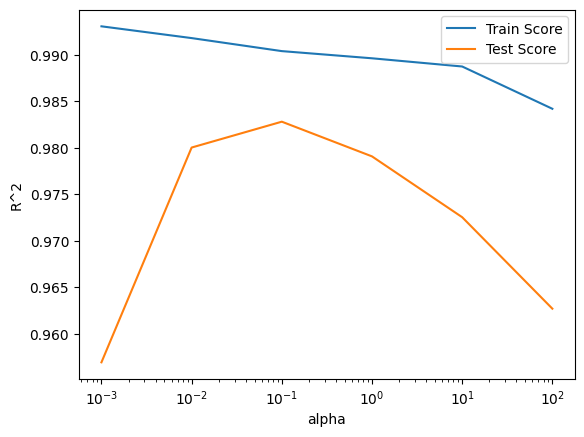

In [28]:
import matplotlib.pyplot as plt

train_score = []
test_score = []

alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]

for alpha in alpha_list:
    ridge = Ridge(alpha=alpha)

    ridge.fit(train_scaled, train_target)

    train_score.append(ridge.score(train_scaled, train_target))
    test_score.append(ridge.score(test_scaled, test_target))

plt.plot(alpha_list, train_score, label='Train Score')
plt.plot(alpha_list, test_score, label='Test Score')

plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("R^2")
plt.legend() # Add legend to display labels

plt.show()

# 최적값 = 0.1

In [29]:
# Ridge_2 (Hyperparmetet)

ridge = Ridge(alpha=0.1)

ridge.fit(train_scaled, train_target)

print(f"train score: {ridge.score(train_scaled, train_target)}")
print(f"test score: {ridge.score(test_scaled, test_target)}")

train score: 0.9903815817570367
test score: 0.9827976465386928


### **3.2 Lasso Model**

In [30]:
# Lasso Model
from sklearn.linear_model import Lasso

lasso = Lasso()

lasso.fit(train_scaled, train_target)

print(lasso.score(train_scaled, train_target))


0.989789897208096


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.336e+04, tolerance: 5.183e+02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.025e+04, tolerance: 5.183e+02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.062e+02, tolerance: 5.183e

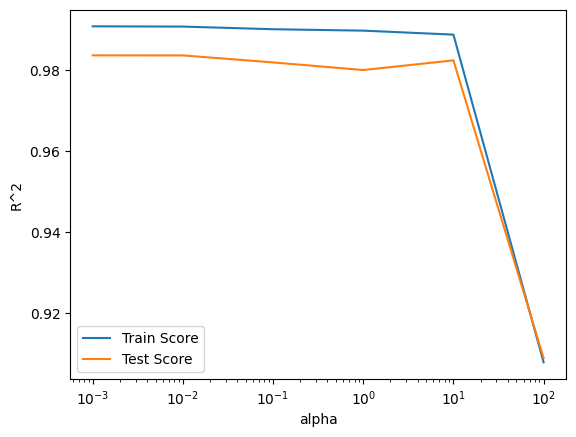

In [31]:
import matplotlib.pyplot as plt

train_score = []
test_score = []

alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]

for alpha in alpha_list:
    lasso = Lasso(alpha=alpha)

    lasso.fit(train_scaled, train_target)

    train_score.append(lasso.score(train_scaled, train_target))
    test_score.append(lasso.score(test_scaled, test_target))

plt.plot(alpha_list, train_score, label='Train Score')
plt.plot(alpha_list, test_score, label='Test Score')

plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("R^2")
plt.legend() # Add legend to display labels

plt.show()

# 최적값 = 10

In [32]:
# Lasso_2 (Hyperparmetet)

lasso = Lasso(alpha=10)

lasso.fit(train_scaled, train_target)

print(f"train score: {lasso.score(train_scaled, train_target)}")
print(f"test score: {lasso.score(test_scaled, test_target)}")

train score: 0.9888067471131867
test score: 0.9824470598706695


## **4. 자유 주제**

### **4.1 Hyperparameter**

- N차 다항식을 적용했을 때 특성의 개수가 급격히 늘어나면서 훈련 세트에만 과도하게 최적화 됨. 그 결과 테스트 세트의 점수가 -144로 나타나는 과적합이 발생

- 이에 따라```GridSearchCV```를 통해 최적의 규제 강도 ```alpha```를 산출

- 학습 곡선에서 기존 값( ```alpha=0.1```)와 최적 값(```alpha=10```) 간 학습 정도를 비교

- 그 결과, CV를 걸쳐 확인한 최적의 ```alpha```를 적용했을 때 훈련세트와 테스트 세트의 점수 차이가 줄어들며 모델이 안정적으로 일반화 됨을 알 수 있었음


In [33]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Ridge 모델과 alpha 값 후보 리스트 설정
ridge = Ridge()
alpha_params = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

# GridSearchCV 설정
grid_ridge = GridSearchCV(ridge, param_grid=alpha_params, cv=5, scoring='r2')

# 훈련 데이터(스케일링된 데이터)를 사용하여 최적의 alpha 값 탐색
grid_ridge.fit(train_scaled, train_target)

print(f"최적의 alpha 값: {grid_ridge.best_params_['alpha']}")
print(f"최고 R^2 점수: {grid_ridge.best_score_:.4f}")

# 최적의 alpha 값으로 다시 모델을 훈련하고 test set에 대한 점수 확인
best_ridge = grid_ridge.best_estimator_
print(f"Test Set Score (with best alpha): {best_ridge.score(test_scaled, test_target):.4f}")

최적의 alpha 값: 10
최고 R^2 점수: 0.9827
Test Set Score (with best alpha): 0.9725


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:2180: RuntimeWarning: Removed duplicate entries from 'train_sizes'. Number of ticks will be less than the size of 'train_sizes': 31 instead of 50.
  warnings.warn(


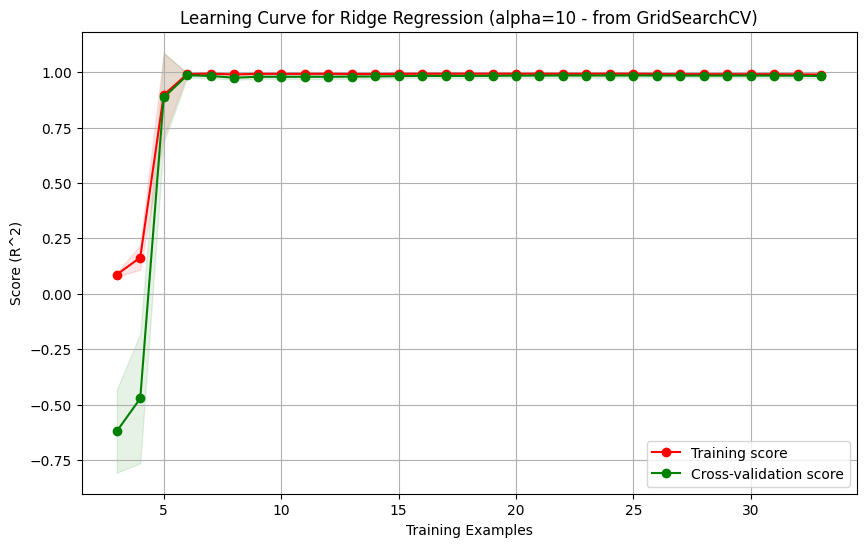

In [35]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

# GridSearchCV를 통해 찾은 최적의 alpha 값 (10)을 가진 Ridge 모델
best_ridge_alpha_10 = Ridge(alpha=10)

# 학습 곡선 생성
train_sizes_10, train_scores_10, test_scores_10 = learning_curve(
    best_ridge_alpha_10, train_scaled, train_target, cv=5, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 50)
)

# 훈련 스코어와 테스트 스코어의 평균 및 표준편차 계산
train_scores_mean_10 = np.mean(train_scores_10, axis=1)
train_scores_std_10 = np.std(train_scores_10, axis=1)
test_scores_mean_10 = np.mean(test_scores_10, axis=1)
test_scores_std_10 = np.std(test_scores_10, axis=1)

# 학습 곡선 시각화
plt.figure(figsize=(10, 6))
plt.title("Learning Curve for Ridge Regression (alpha=10 - from GridSearchCV)")
plt.xlabel("Training Examples")
plt.ylabel("Score (R^2)")
plt.grid(True)

# 훈련 스코어 플로팅
plt.plot(train_sizes_10, train_scores_mean_10, 'o-', color="r", label="Training score")
plt.fill_between(train_sizes_10, train_scores_mean_10 - train_scores_std_10,
                 train_scores_mean_10 + train_scores_std_10, alpha=0.1, color="r")

# 테스트 스코어 플로팅
plt.plot(train_sizes_10, test_scores_mean_10, 'o-', color="g", label="Cross-validation score")
plt.fill_between(train_sizes_10, test_scores_mean_10 - test_scores_std_10,
                 test_scores_mean_10 + test_scores_std_10, alpha=0.1, color="g")

plt.legend(loc="best")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:2180: RuntimeWarning: Removed duplicate entries from 'train_sizes'. Number of ticks will be less than the size of 'train_sizes': 31 instead of 50.
  warnings.warn(


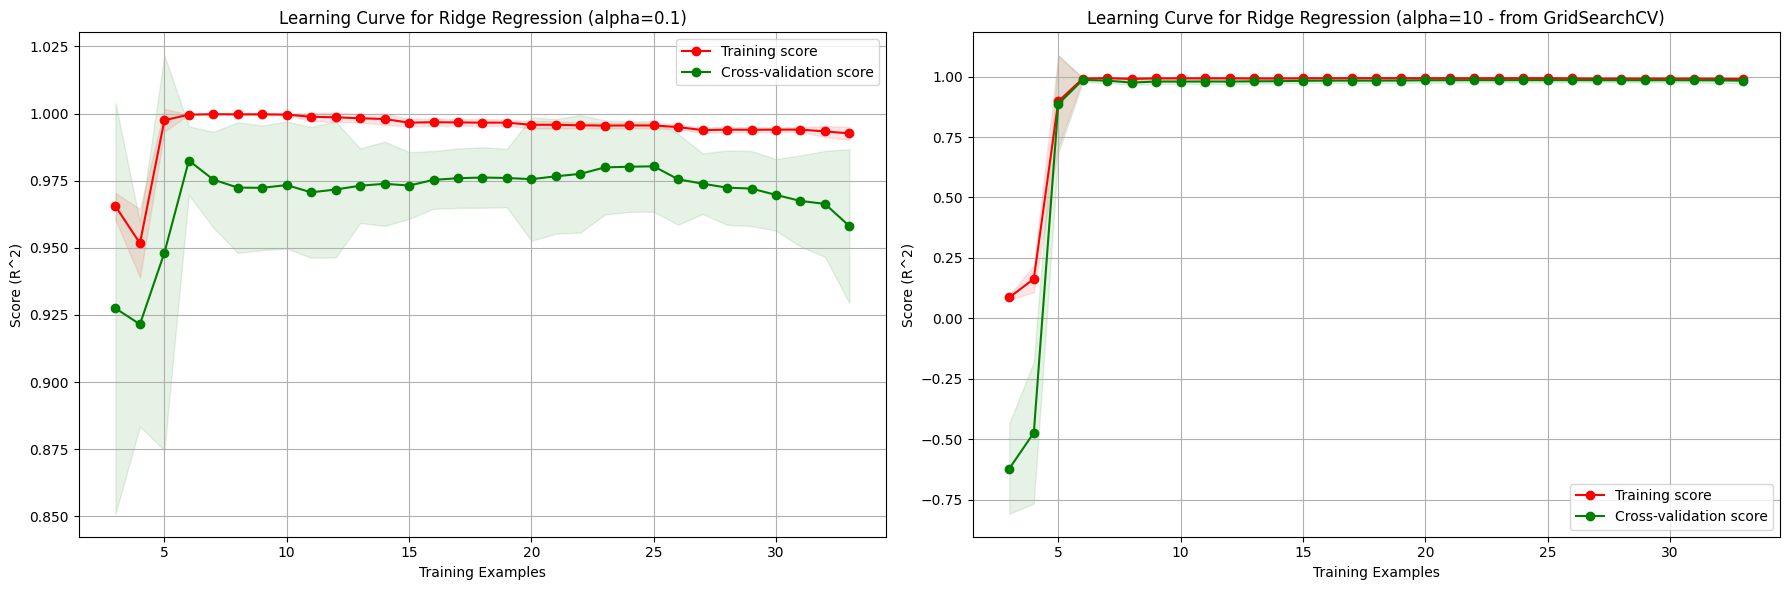

In [36]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

# --- Ridge 모델 (alpha=0.1) 학습 곡선 데이터 생성 ---
ridge_alpha_0_1 = Ridge(alpha=0.1)
train_sizes_0_1, train_scores_0_1, test_scores_0_1 = learning_curve(
    ridge_alpha_0_1, train_scaled, train_target, cv=5, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 50)
)

train_scores_mean_0_1 = np.mean(train_scores_0_1, axis=1)
train_scores_std_0_1 = np.std(train_scores_0_1, axis=1)
test_scores_mean_0_1 = np.mean(test_scores_0_1, axis=1)
test_scores_std_0_1 = np.std(test_scores_0_1, axis=1)

# --- Ridge 모델 (alpha=10) 학습 곡선 데이터 생성 ---
ridge_alpha_10 = Ridge(alpha=10)
train_sizes_10, train_scores_10, test_scores_10 = learning_curve(
    ridge_alpha_10, train_scaled, train_target, cv=5, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 50)
)

train_scores_mean_10 = np.mean(train_scores_10, axis=1)
train_scores_std_10 = np.std(train_scores_10, axis=1)
test_scores_mean_10 = np.mean(test_scores_10, axis=1)
test_scores_std_10 = np.std(test_scores_10, axis=1)

# --- 학습 곡선 시각화 (두 개의 서브플롯) ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Subplot 1: alpha = 0.1
axes[0].set_title("Learning Curve for Ridge Regression (alpha=0.1)")
axes[0].set_xlabel("Training Examples")
axes[0].set_ylabel("Score (R^2)")
axes[0].grid(True)
axes[0].plot(train_sizes_0_1, train_scores_mean_0_1, 'o-', color="r", label="Training score")
axes[0].fill_between(train_sizes_0_1, train_scores_mean_0_1 - train_scores_std_0_1,
                 train_scores_mean_0_1 + train_scores_std_0_1, alpha=0.1, color="r")
axes[0].plot(train_sizes_0_1, test_scores_mean_0_1, 'o-', color="g", label="Cross-validation score")
axes[0].fill_between(train_sizes_0_1, test_scores_mean_0_1 - test_scores_std_0_1,
                 test_scores_mean_0_1 + test_scores_std_0_1, alpha=0.1, color="g")
axes[0].legend(loc="best")

# Subplot 2: alpha = 10
axes[1].set_title("Learning Curve for Ridge Regression (alpha=10 - from GridSearchCV)")
axes[1].set_xlabel("Training Examples")
axes[1].set_ylabel("Score (R^2)")
axes[1].grid(True)
axes[1].plot(train_sizes_10, train_scores_mean_10, 'o-', color="r", label="Training score")
axes[1].fill_between(train_sizes_10, train_scores_mean_10 - train_scores_std_10,
                 train_scores_mean_10 + train_scores_std_10, alpha=0.1, color="r")
axes[1].plot(train_sizes_10, test_scores_mean_10, 'o-', color="g", label="Cross-validation score")
axes[1].fill_between(train_sizes_10, test_scores_mean_10 - test_scores_std_10,
                 test_scores_mean_10 + test_scores_std_10, alpha=0.1, color="g")
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()

### **4.2 Ridge vs Lasso**

- Ridge(L2 규제): 계수의 제곱에 비례하여 페널티를 부여. 큰 계수를 우선적으로 억제하지만 완전히 0으로 만들지 않음.

    → 데이터의 모든 특성이 유의미하거나, 특성 간의 상관관계가 높을 때(다중공선성 문제)

- Lasso(L1 규제): 계수의 절댓값에 비례하여 페널티를 부여. 특성상 중요도가 낮은 특성의 계수를 0으로 수렴하게 만듦
    
    → 데이터의 모든 특성이 유의미하거나, 특성 간의 상관관계가 높을 때(다중공선성 문제)



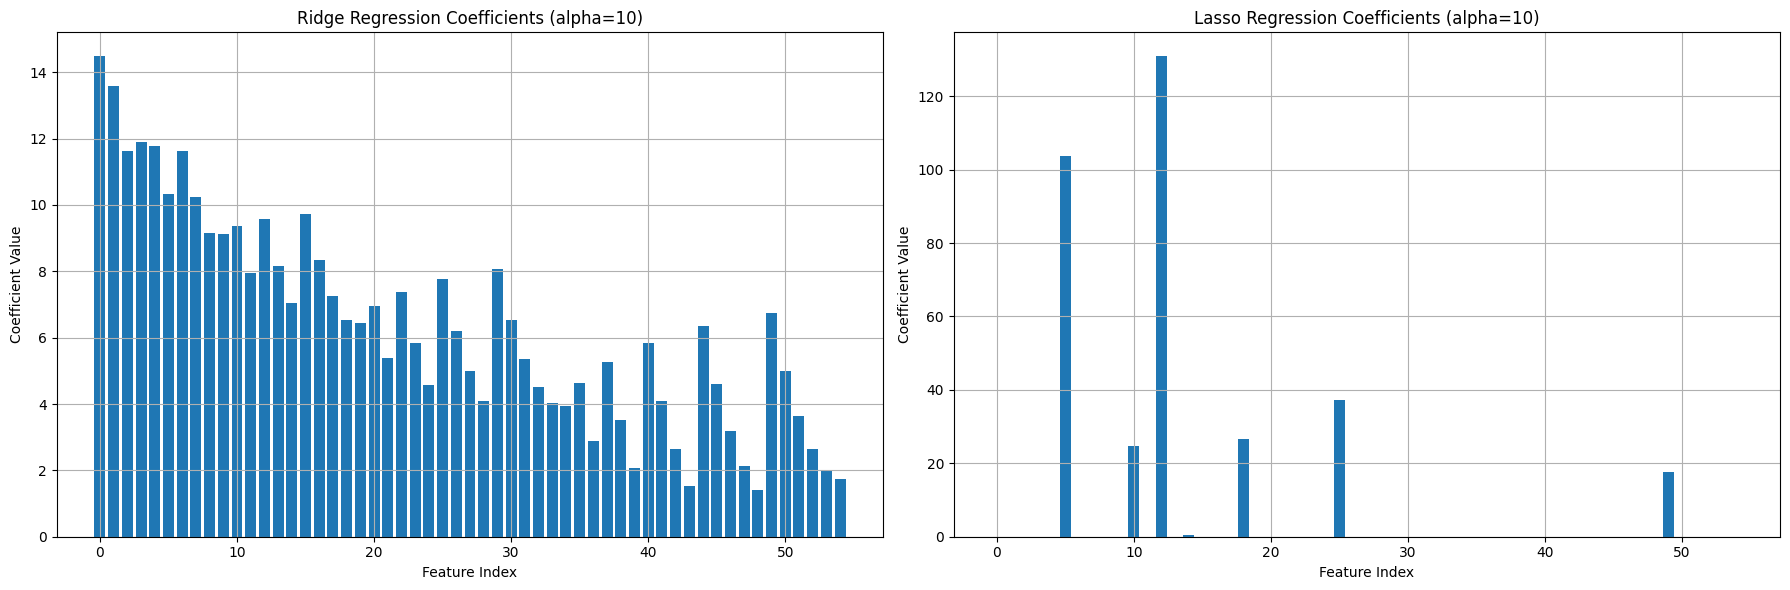


--- Ridge Coefficients (first 10) ---
[14.47787925 13.57602998 11.63201165 11.8932325  11.77752923 10.31858308
 11.64021387 10.24123244  9.14825214  9.1286404 ]

--- Lasso Coefficients (first 10) ---
[  0.           0.           0.           0.           0.
 103.82164392   0.           0.           0.           0.        ]

Number of non-zero coefficients in Ridge: 55
Number of non-zero coefficients in Lasso: 7


In [37]:
from sklearn.linear_model import Ridge, Lasso
import matplotlib.pyplot as plt
import numpy as np

# Ridge 모델 (최적 alpha=10 사용)
ridge_model = Ridge(alpha=10)
ridge_model.fit(train_scaled, train_target)

# Lasso 모델 (최적 alpha=10 사용)
lasso_model = Lasso(alpha=10, max_iter=10000)
lasso_model.fit(train_scaled, train_target)

# 계수 비교를 위한 바 차트
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Ridge 모델 계수
axes[0].bar(range(len(ridge_model.coef_)), ridge_model.coef_)
axes[0].set_title('Ridge Regression Coefficients (alpha=10)')
axes[0].set_xlabel('Feature Index')
axes[0].set_ylabel('Coefficient Value')
axes[0].grid(True)

# Lasso 모델 계수
axes[1].bar(range(len(lasso_model.coef_)), lasso_model.coef_)
axes[1].set_title('Lasso Regression Coefficients (alpha=10)')
axes[1].set_xlabel('Feature Index')
axes[1].set_ylabel('Coefficient Value')
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("\n--- Ridge Coefficients (first 10) ---")
print(ridge_model.coef_[:10])
print("\n--- Lasso Coefficients (first 10) ---")
print(lasso_model.coef_[:10])

print(f"\nNumber of non-zero coefficients in Ridge: {np.sum(ridge_model.coef_ != 0)}")
print(f"Number of non-zero coefficients in Lasso: {np.sum(lasso_model.coef_ != 0)}")

### **4.3. 규제 모델과 Scaler**

- 스케일링 전: 특정 특성의 계수가 비정상적으로 크거나 들쭉날쭉한 특징을 보임 (단순히 단위가 큰 특성의 계수만 억제)

- 스케일링 후: 계수들이 일정한 범위 내에서 안정적으로 형성됨 (일정 범위(평균 0, 표준편차 1) 내에서 규제를 받음)

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=9.95201e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.109e+04, tolerance: 5.183e+02
  model = cd_fast.enet_coordinate_descent(


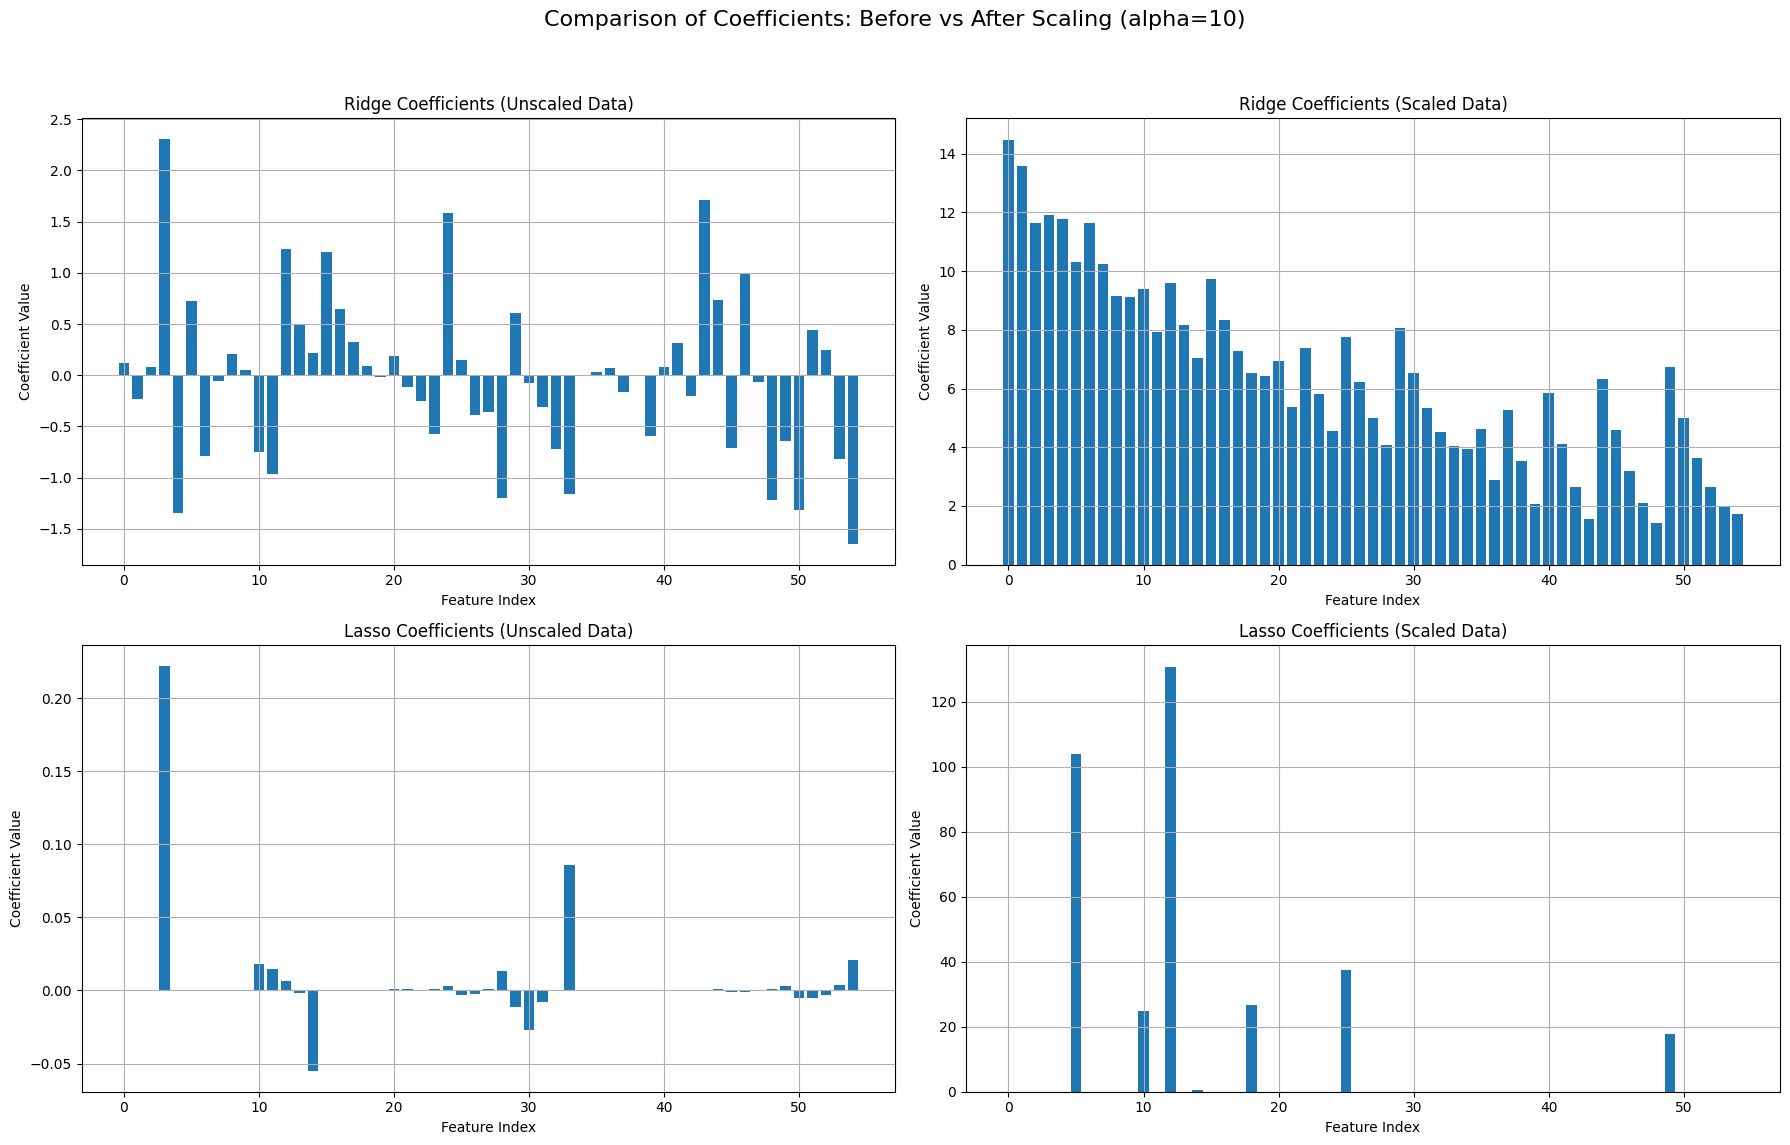


--- Number of non-zero coefficients ---
Ridge (Unscaled): 55
Ridge (Scaled): 55
Lasso (Unscaled): 42
Lasso (Scaled): 7

--- Example coefficients (first 5) ---
Ridge (Unscaled): [ 0.12270117 -0.23359842  0.0848519   2.30959794 -1.34175702]
Ridge (Scaled): [14.47787925 13.57602998 11.63201165 11.8932325  11.77752923]
Lasso (Unscaled): [-0.          0.         -0.          0.22216145  0.        ]
Lasso (Scaled): [0. 0. 0. 0. 0.]


In [38]:
from sklearn.linear_model import Ridge, Lasso
import matplotlib.pyplot as plt
import numpy as np

# --- 모델 학습: 스케일링 전/후 비교 ---

# 1. Ridge 모델 (스케일링 전) - alpha=10
ridge_unscaled = Ridge(alpha=10)
ridge_unscaled.fit(train_poly, train_target)

# 2. Ridge 모델 (스케일링 후) - alpha=10 (이전 GridSearchCV에서 최적)
# train_scaled는 이미 ss.transform(train_poly)로 생성되었으므로 재사용
ridge_scaled = Ridge(alpha=10)
ridge_scaled.fit(train_scaled, train_target)

# 3. Lasso 모델 (스케일링 전) - alpha=10
lasso_unscaled = Lasso(alpha=10, max_iter=10000)
lasso_unscaled.fit(train_poly, train_target)

# 4. Lasso 모델 (스케일링 후) - alpha=10 (이전 분석에서 최적)
# train_scaled는 이미 ss.transform(train_poly)로 생성되었으므로 재사용
lasso_scaled = Lasso(alpha=10, max_iter=10000)
lasso_scaled.fit(train_scaled, train_target)

# --- 계수 시각화 ---

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Comparison of Coefficients: Before vs After Scaling (alpha=10)', fontsize=16)

# Subplot 1: Ridge (스케일링 전)
axes[0, 0].bar(range(len(ridge_unscaled.coef_)), ridge_unscaled.coef_)
axes[0, 0].set_title('Ridge Coefficients (Unscaled Data)')
axes[0, 0].set_xlabel('Feature Index')
axes[0, 0].set_ylabel('Coefficient Value')
axes[0, 0].grid(True)

# Subplot 2: Ridge (스케일링 후)
axes[0, 1].bar(range(len(ridge_scaled.coef_)), ridge_scaled.coef_)
axes[0, 1].set_title('Ridge Coefficients (Scaled Data)')
axes[0, 1].set_xlabel('Feature Index')
axes[0, 1].set_ylabel('Coefficient Value')
axes[0, 1].grid(True)

# Subplot 3: Lasso (스케일링 전)
axes[1, 0].bar(range(len(lasso_unscaled.coef_)), lasso_unscaled.coef_)
axes[1, 0].set_title('Lasso Coefficients (Unscaled Data)')
axes[1, 0].set_xlabel('Feature Index')
axes[1, 0].set_ylabel('Coefficient Value')
axes[1, 0].grid(True)

# Subplot 4: Lasso (스케일링 후)
axes[1, 1].bar(range(len(lasso_scaled.coef_)), lasso_scaled.coef_)
axes[1, 1].set_title('Lasso Coefficients (Scaled Data)')
axes[1, 1].set_xlabel('Feature Index')
axes[1, 1].set_ylabel('Coefficient Value')
axes[1, 1].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

print("\n--- Number of non-zero coefficients ---")
print(f"Ridge (Unscaled): {np.sum(ridge_unscaled.coef_ != 0)}")
print(f"Ridge (Scaled): {np.sum(ridge_scaled.coef_ != 0)}")
print(f"Lasso (Unscaled): {np.sum(lasso_unscaled.coef_ != 0)}")
print(f"Lasso (Scaled): {np.sum(lasso_scaled.coef_ != 0)}")

print("\n--- Example coefficients (first 5) ---")
print(f"Ridge (Unscaled): {ridge_unscaled.coef_[:5]}")
print(f"Ridge (Scaled): {ridge_scaled.coef_[:5]}")
print(f"Lasso (Unscaled): {lasso_unscaled.coef_[:5]}")
print(f"Lasso (Scaled): {lasso_scaled.coef_[:5]}")